## Summary:

This notebook evaluates the reconstruction fidelity of the autoencoder by comparing original physical inputs against their decoded counterparts for varying settings of the bottleneck size.

## Requirements:

- You need to have generated or saved ham-terms and two-rdm instances 
- You need to have trained or saved models for system sizes ```L_{ham-term}=[4,6,8,10,12,14]``` and```L_{two-rdm}=[4,6,8]```






In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from dftqml.autoencoders.ae import load_model
import torch
import torch.nn.functional as F
from dftqml.autoencoders import autoencoder_utils

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

# Reconstruction Loss

In [2]:
iter_dict = {}
input_type = "ham_terms"

for i in range(3):
    loss_dict = {}

    for L in [4, 6, 8, 10, 12, 14]:
        loss_dict[L] = []
        for z in [L - 3, L - 2, L - 1, L, L + 1, L + 2]:

            checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=i,
                linear_encoder=False,
                augment_by_symmetry=True
                )

            checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

            model = load_model(checkpoint_dir, device="cpu")

            n_test_data = 10000

            data_path = f"../data/L{L}-N{L}-U4.0_reduced.hdf5"
            with h5py.File(data_path, "r") as f:
                x = f["hamiltonian_terms"][-n_test_data + 1 :]

            input_vector = torch.Tensor(x.reshape((9999, L * 3)))
            recon_vector = model(input_vector)
            input_vector = torch.Tensor(x)

            loss_dict[L].append(
                np.sqrt(
                    F.mse_loss(input_vector, recon_vector, reduction="mean")
                    .detach()
                    .numpy()
                )
            )
    iter_dict[i] = loss_dict

(tensor(4.0579, grad_fn=<SumBackward0>), tensor(3.3919, grad_fn=<SumBackward0>))
(tensor(3.9933, grad_fn=<SumBackward0>), tensor(3.6083, grad_fn=<SumBackward0>))
(tensor(3.9599, grad_fn=<SumBackward0>), tensor(3.5890, grad_fn=<SumBackward0>))
(tensor(4.1131, grad_fn=<SumBackward0>), tensor(3.6911, grad_fn=<SumBackward0>))
(tensor(4.0216, grad_fn=<SumBackward0>), tensor(3.7778, grad_fn=<SumBackward0>))
(tensor(4.0856, grad_fn=<SumBackward0>), tensor(3.7624, grad_fn=<SumBackward0>))
(tensor(4.6010, grad_fn=<SumBackward0>), tensor(4.0453, grad_fn=<SumBackward0>))
(tensor(4.5779, grad_fn=<SumBackward0>), tensor(4.1026, grad_fn=<SumBackward0>))
(tensor(4.5738, grad_fn=<SumBackward0>), tensor(4.1325, grad_fn=<SumBackward0>))
(tensor(4.6735, grad_fn=<SumBackward0>), tensor(4.2093, grad_fn=<SumBackward0>))
(tensor(4.6419, grad_fn=<SumBackward0>), tensor(4.2815, grad_fn=<SumBackward0>))
(tensor(4.6276, grad_fn=<SumBackward0>), tensor(4.2800, grad_fn=<SumBackward0>))
(tensor(4.9840, grad_fn=<Sum

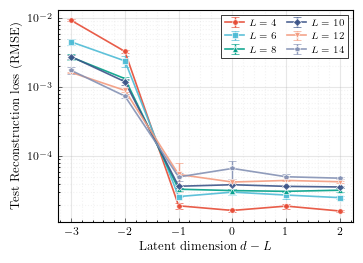

In [3]:
def plot_reconstruction_loss_iter(iter_dict):
    """
    Create a plot of latent dimension vs reconstruction loss.

    Parameters
    ----------
    loss_dict : dict
        Dictionary with keys as system sizes L and values as lists of losses
        for different latent dimensions [L-3, L-2, L-1, L, L+1, L+2]

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Nature single column width (~3.5 inches)
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    # Nature-style color palette (colorblind-friendly)
    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]

    # Marker styles for visual distinction
    markers = ["o", "s", "^", "D", "v", "p"]

    L_values = sorted(loss_dict.keys())

    for idx, L in enumerate(L_values):
        losses = np.array([iter_dict[i][L] for i in range(3)])  # shape: (n_iter, 6)

        mean_losses = losses.mean(axis=0)  # shape: (6,)
        std_losses = losses.std(axis=0)

        z_minus_L = [-3, -2, -1, 0, 1, 2]

        ax.errorbar(
            z_minus_L,
            mean_losses,
            yerr=std_losses,
            marker=markers[idx],
            markersize=4,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            capsize=3,
            capthick=1,
            elinewidth=1,
            alpha=0.9,
        )

    # Set log scale for y-axis
    ax.set_yscale("log")

    # Add grid
    ax.grid(True, which="major", linestyle="-", alpha=0.3)
    ax.grid(True, which="minor", linestyle=":", alpha=0.15)
    # ax.grid(True, linestyle='--', alpha=0.7)

    # Labels
    ax.set_xlabel(r"Latent dimension $d - L$", fontsize=9)
    ax.set_ylabel(r"Test Reconstruction loss (RMSE)", fontsize=9)

    # Set integer x-axis ticks
    ax.set_xticks([-3, -2, -1, 0, 1, 2])

    # Legend with Nature style
    legend = ax.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=2,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
    legend.get_frame().set_linewidth(0.6)

    # Tick parameters
    ax.tick_params(direction="in", which="both", labelsize=8)
    ax.tick_params(which="major", length=3)
    ax.tick_params(which="minor", length=1.5)

    # Add minor ticks
    ax.minorticks_on()

    # Spine customization
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    fig.tight_layout(pad=0.3)

    return fig


fig = plot_reconstruction_loss_iter(iter_dict)
# fig.savefig("reconstruction_loss.pdf", dpi=300, bbox_inches="tight")

In [4]:
iter_dict = {}
input_type = "two_rdms"

for i in range(3):
    loss_dict = {}

    for L in [4, 6, 8]:
        loss_dict[L] = []
        for z in [L - 3, L - 2, L - 1, L, L + 1, L + 2]:

            checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=i,
                linear_encoder=False,
                augment_by_symmetry=False
                )

            checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

            model = load_model(checkpoint_dir, device="cpu")

            n_test_data = 10000

            data_path = f"../data/L{L}-N{L}-U4.0.hdf5"
            with h5py.File(data_path, "r") as f:
                x = f["two_rdms"][-n_test_data + 1 :]

            input_vector = torch.Tensor(x.reshape((9999, L**4)))
            recon_vector = model(input_vector)
            input_vector = torch.Tensor(x)

            loss_dict[L].append(
                np.sqrt(
                    F.mse_loss(input_vector, recon_vector, reduction="mean")
                    .detach()
                    .numpy()
                )
            )
    iter_dict[i] = loss_dict

(tensor(5.0809, grad_fn=<SumBackward0>), tensor(3.2772, grad_fn=<SumBackward0>))
(tensor(5.1061, grad_fn=<SumBackward0>), tensor(3.4080, grad_fn=<SumBackward0>))
(tensor(5.1392, grad_fn=<SumBackward0>), tensor(3.5555, grad_fn=<SumBackward0>))
(tensor(5.0629, grad_fn=<SumBackward0>), tensor(3.5694, grad_fn=<SumBackward0>))
(tensor(5.1345, grad_fn=<SumBackward0>), tensor(3.6382, grad_fn=<SumBackward0>))
(tensor(5.0979, grad_fn=<SumBackward0>), tensor(3.6952, grad_fn=<SumBackward0>))
(tensor(6.4838, grad_fn=<SumBackward0>), tensor(4.2730, grad_fn=<SumBackward0>))
(tensor(6.5014, grad_fn=<SumBackward0>), tensor(4.3103, grad_fn=<SumBackward0>))
(tensor(6.4553, grad_fn=<SumBackward0>), tensor(4.4071, grad_fn=<SumBackward0>))
(tensor(6.4891, grad_fn=<SumBackward0>), tensor(4.4066, grad_fn=<SumBackward0>))
(tensor(6.4764, grad_fn=<SumBackward0>), tensor(4.4595, grad_fn=<SumBackward0>))
(tensor(6.4160, grad_fn=<SumBackward0>), tensor(4.4753, grad_fn=<SumBackward0>))
(tensor(7.4380, grad_fn=<Sum

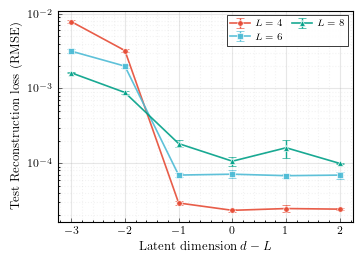

In [5]:
fig = plot_reconstruction_loss_iter(iter_dict)
# fig.savefig("reconstruction_loss_2rdm.pdf", dpi=300, bbox_inches="tight")